# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 Load and Explore the RealWaste Dataset

In [1]:
# EcoSort Waste Management Assistant
# Environment setup and reproducibility

import os
import re
import json
import random
import pathlib
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from PIL import Image
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Environment initialized successfully.")

TensorFlow version: 2.21.0
Environment initialized successfully.


RealWaste root: RealWaste\realwaste-main\RealWaste

Waste categories:
- Cardboard
- Food Organics
- Glass
- Metal
- Miscellaneous Trash
- Paper
- Plastic
- Textile Trash
- Vegetation

Number of categories: 9

Images per category:
Cardboard: 461
Food Organics: 411
Glass: 420
Metal: 790
Miscellaneous Trash: 495
Paper: 500
Plastic: 921
Textile Trash: 318
Vegetation: 436

Total images: 4752


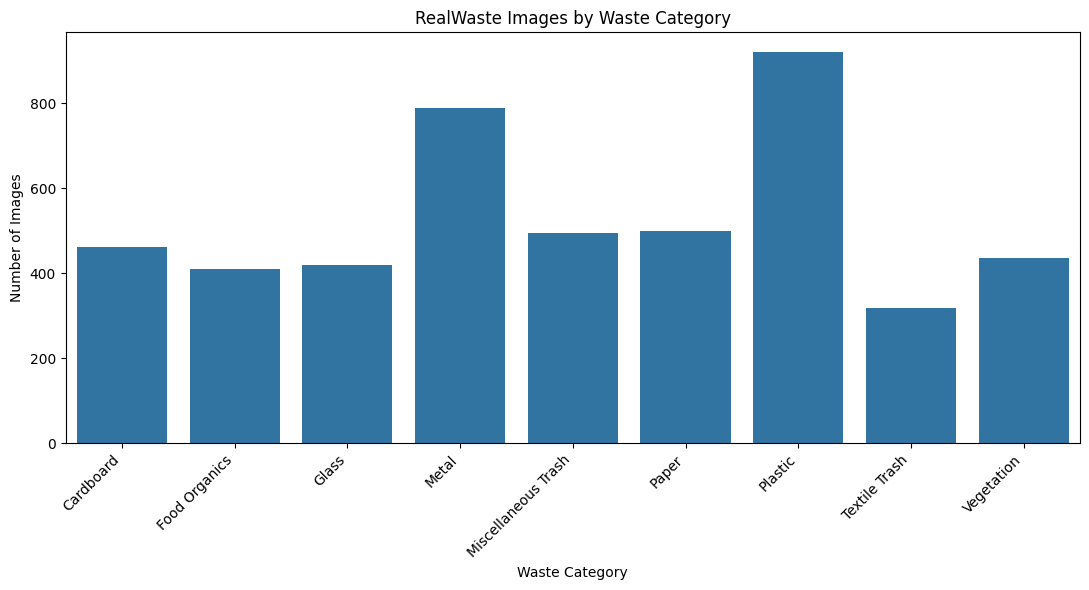


Sample image characteristics:


,width,height,mode,format
count,100.0,100.0,100,100
unique,NaN,NaN,1,1
top,NaN,NaN,RGB,JPEG
freq,NaN,NaN,100,100
mean,524.0,524.0,NaN,NaN
std,0.0,0.0,NaN,NaN
min,524.0,524.0,NaN,NaN
25%,524.0,524.0,NaN,NaN
50%,524.0,524.0,NaN,NaN
75%,524.0,524.0,NaN,NaN


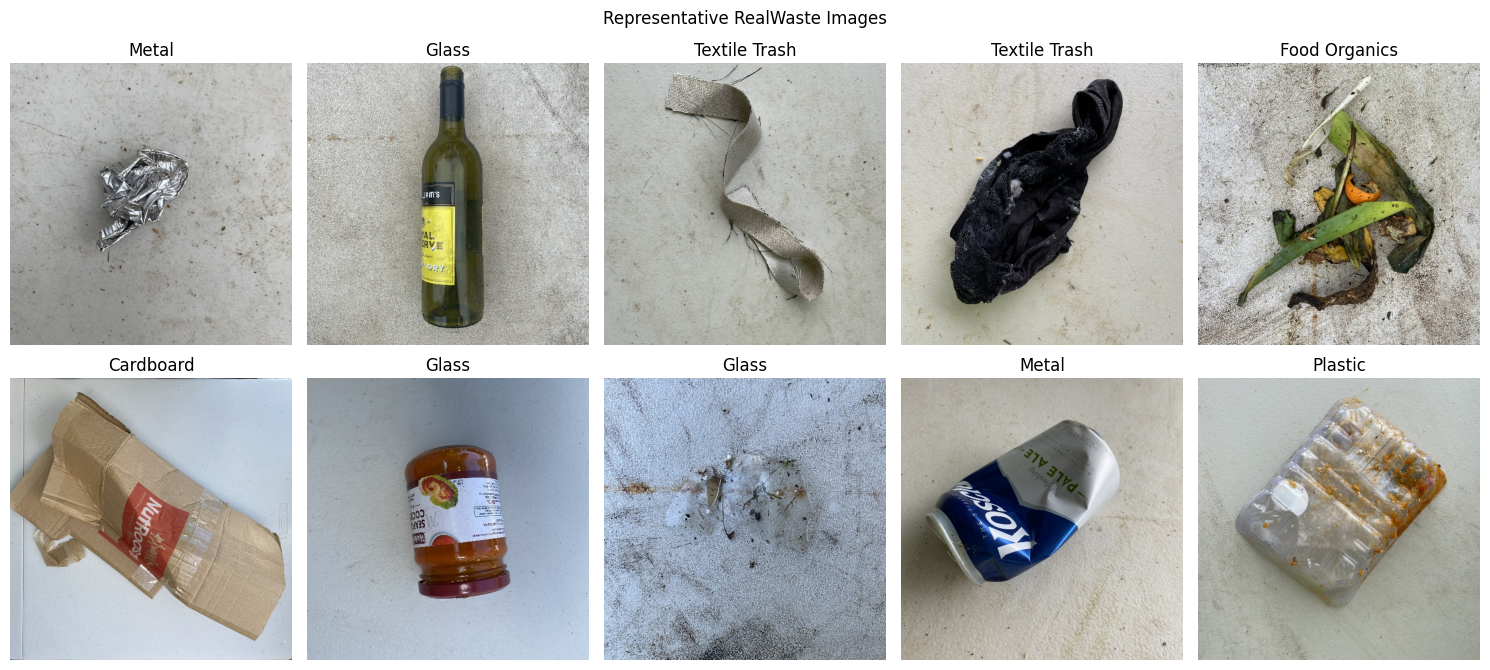

In [2]:
# 1.1 Load and explore the RealWaste dataset
# The downloaded dataset may contain an outer wrapper such as "realwaste-main".
# This cell automatically locates the folder whose immediate subfolders are the
# actual waste categories.

EXPECTED_CATEGORIES = {
    "Cardboard", "Food Organics", "Glass", "Metal",
    "Miscellaneous Trash", "Paper", "Plastic",
    "Textile Trash", "Vegetation"
}
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def contains_images(folder):
    """Return True when a folder contains at least one supported image."""
    return any(
        p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        for p in folder.rglob("*")
    )

def find_realwaste_root(start_path="RealWaste"):
    """
    Locate the RealWaste directory that directly contains the class folders.
    Handles common structures such as:
        RealWaste/<9 classes>/
        RealWaste/realwaste-main/<9 classes>/
    """
    start = pathlib.Path(start_path)

    if not start.exists():
        raise FileNotFoundError(
            f"Could not find '{start_path}'. Place the RealWaste dataset "
            "folder beside this notebook and run the cell again."
        )

    candidates = [start] + [p for p in start.rglob("*") if p.is_dir()]

    # Prefer a directory containing the expected nine class names.
    for folder in candidates:
        subdirs = {p.name for p in folder.iterdir() if p.is_dir()}
        if EXPECTED_CATEGORIES.issubset(subdirs):
            return folder

    # Fallback: choose a directory with several image-containing subfolders.
    fallback = []
    for folder in candidates:
        subdirs = [p for p in folder.iterdir() if p.is_dir()]
        image_subdirs = [p for p in subdirs if contains_images(p)]
        if len(image_subdirs) >= 2:
            fallback.append((len(image_subdirs), folder))

    if fallback:
        return max(fallback, key=lambda x: x[0])[1]

    raise FileNotFoundError(
        "The RealWaste class folders could not be located. "
        "Check that the dataset has been downloaded and extracted."
    )

data_dir = find_realwaste_root("RealWaste")
class_names = sorted([p.name for p in data_dir.iterdir() if p.is_dir()])

print("RealWaste root:", data_dir)
print("\nWaste categories:")
for category in class_names:
    print("-", category)

print("\nNumber of categories:", len(class_names))

class_counts = {}
for category in class_names:
    category_path = data_dir / category
    class_counts[category] = sum(
        1 for file in category_path.rglob("*")
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    )

print("\nImages per category:")
for category, count in class_counts.items():
    print(f"{category}: {count}")

print("\nTotal images:", sum(class_counts.values()))

# Visualize class distribution.
plt.figure(figsize=(11, 6))
sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)
plt.title("RealWaste Images by Waste Category")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Inspect image dimensions and channels using a small random sample.
image_files = [
    p for p in data_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]
sample_files = random.sample(image_files, min(100, len(image_files)))

image_info = []
for file in sample_files:
    try:
        with Image.open(file) as img:
            image_info.append({
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
                "format": img.format
            })
    except Exception:
        continue

image_info_df = pd.DataFrame(image_info)

print("\nSample image characteristics:")
display(image_info_df.describe(include="all"))

# Show representative images.
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for ax, file in zip(axes.flat, random.sample(image_files, min(10, len(image_files)))):
    with Image.open(file) as img:
        ax.imshow(img.convert("RGB"))
    ax.set_title(file.parent.name)
    ax.axis("off")

plt.suptitle("Representative RealWaste Images")
plt.tight_layout()
plt.show()

### Exploration note
The dataset loader is deliberately robust to the common `RealWaste/realwaste-main/<category>/...` extraction structure. The analysis reports category balance and samples image dimensions so potential visual challenges can be identified before modelling.

### 1.2 Explore Text Datasets

In [3]:
# 1.2 Explore the waste description text data

description_path = pathlib.Path("waste_descriptions.csv")

if not description_path.exists():
    raise FileNotFoundError(
        "waste_descriptions.csv was not found. Place it in the same folder "
        "as this notebook."
    )

descriptions_df = pd.read_csv(description_path)

required_description_columns = {"category", "description"}
missing = required_description_columns - set(descriptions_df.columns)
if missing:
    raise ValueError(f"Missing required columns in waste_descriptions.csv: {missing}")

print("Waste Descriptions Preview:")
display(descriptions_df.head())

print("\nDataset shape:", descriptions_df.shape)
print("\nColumns:", descriptions_df.columns.tolist())

print("\nMissing values:")
display(descriptions_df.isnull().sum())

print("\nCategory distribution:")
display(descriptions_df["category"].value_counts())

# Basic vocabulary/length analysis.
descriptions_df["description_length"] = (
    descriptions_df["description"].fillna("").astype(str).str.split().str.len()
)

print("\nDescription length statistics:")
display(descriptions_df["description_length"].describe())

vocabulary = set()
for text in descriptions_df["description"].fillna("").astype(str):
    vocabulary.update(clean_word for clean_word in re.findall(r"\b[a-zA-Z]+\b", text.lower()))

print("Approximate vocabulary size:", len(vocabulary))

Waste Descriptions Preview:


,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...



Dataset shape: (5000, 5)

Columns: ['description', 'category', 'disposal_instruction', 'common_confusion', 'material_composition']

Missing values:


description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64


Category distribution:


category
Vegetation             600
Textile Trash          586
Cardboard              584
Miscellaneous Trash    578
Plastic                569
Glass                  551
Food Organics          518
Metal                  508
Paper                  506
Name: count, dtype: int64


Description length statistics:


count    5000.000000
mean        4.854000
std         1.549956
min         1.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: description_length, dtype: float64

Approximate vocabulary size: 309


In [4]:
# 1.2 Explore the waste policy documents
# The assignment materials may be supplied as CSV or JSON. This loader supports both.

def load_policy_documents():
    csv_path = pathlib.Path("waste_policy_documents.csv")
    json_path = pathlib.Path("waste_policy_documents.json")

    if csv_path.exists():
        df = pd.read_csv(csv_path)
    elif json_path.exists():
        with open(json_path, "r", encoding="utf-8") as f:
            raw = json.load(f)

        # Support either a list of documents or a dictionary containing records.
        if isinstance(raw, dict):
            if "documents" in raw and isinstance(raw["documents"], list):
                raw = raw["documents"]
            else:
                raw = [raw]

        df = pd.DataFrame(raw)
    else:
        raise FileNotFoundError(
            "Neither waste_policy_documents.csv nor waste_policy_documents.json "
            "was found. Place the supplied policy file beside this notebook."
        )

    return df

policies_df = load_policy_documents()

required_policy_columns = {"policy_type", "document_text"}
missing = required_policy_columns - set(policies_df.columns)
if missing:
    raise ValueError(f"Missing required policy columns: {missing}")

print("Policy Documents Preview:")
display(policies_df.head())

print("\nPolicy dataset shape:", policies_df.shape)
print("\nColumns:", policies_df.columns.tolist())

print("\nMissing values:")
display(policies_df.isnull().sum())

print("\nPolicy types:")
display(policies_df["policy_type"].value_counts())

if "categories_covered" in policies_df.columns:
    print("\nExample categories covered:")
    display(policies_df[["policy_type", "categories_covered"]].head())

Policy Documents Preview:


,policy_id,policy_type,categories_covered,effective_date,document_text,jurisdiction
0,1,Textile Trash Recycling Guidelines,[Textile Trash],2023-11-04,TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
1,2,Glass Recycling Guidelines,[Glass],2023-01-24,GLASS RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
2,3,Food Organics Recycling Guidelines,[Food Organics],2023-05-08,FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...,Metro City
3,4,Plastic Recycling Guidelines,[Plastic],2023-04-05,PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
4,5,Vegetation Recycling Guidelines,[Vegetation],2023-12-04,VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...,Metro City



Policy dataset shape: (14, 6)

Columns: ['policy_id', 'policy_type', 'categories_covered', 'effective_date', 'document_text', 'jurisdiction']

Missing values:


policy_id             0
policy_type           0
categories_covered    0
effective_date        0
document_text         0
jurisdiction          0
dtype: int64


Policy types:


policy_type
Textile Trash Recycling Guidelines          1
Glass Recycling Guidelines                  1
Food Organics Recycling Guidelines          1
Plastic Recycling Guidelines                1
Vegetation Recycling Guidelines             1
Cardboard Recycling Guidelines              1
Metal Recycling Guidelines                  1
Paper Recycling Guidelines                  1
Miscellaneous Trash Recycling Guidelines    1
Municipal Waste Guidelines                  1
Residential Recycling Rules                 1
Commercial Recycling Standards              1
Multi-Unit Building Guidelines              1
Community Recycling Program                 1
Name: count, dtype: int64


Example categories covered:


,policy_type,categories_covered
0,Textile Trash Recycling Guidelines,[Textile Trash]
1,Glass Recycling Guidelines,[Glass]
2,Food Organics Recycling Guidelines,[Food Organics]
3,Plastic Recycling Guidelines,[Plastic]
4,Vegetation Recycling Guidelines,[Vegetation]


### 1.3 Create Data Pipelines

In [5]:
# 1.3 Create the image data pipeline
# 70% training, 15% validation, and 15% test.
# Images are resized to 224 x 224 and labels are one-hot encoded.

BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224
AUTOTUNE = tf.data.AUTOTUNE

num_classes = len(class_names)

print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")
print(f"Total images found: {sum(class_counts.values())}")

# First create a 70/30 train/temporary split.
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# Split the 30% temporary set approximately equally into validation and test.
temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()
split_batch = max(1, temp_batches // 2)

test_dataset = temp_ds.take(split_batch)
validation_ds = temp_ds.skip(split_batch)

print(f"\nTraining batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Validation batches: {tf.data.experimental.cardinality(validation_ds).numpy()}")
print(f"Test batches: {tf.data.experimental.cardinality(test_dataset).numpy()}")

# Cache and prefetch for faster training.
train_ds = train_ds.cache().prefetch(AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images found: 4752
Found 4752 files belonging to 9 classes.
Using 3327 files for training.
Found 4752 files belonging to 9 classes.
Using 1425 files for validation.

Training batches: 104
Validation batches: 23
Test batches: 22


In [6]:
# 1.3 Text preprocessing pipeline

def clean_text(text):
    """
    Clean text by:
    - converting to lowercase
    - removing URLs
    - removing punctuation
    - removing extra whitespace
    """
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_text = descriptions_df.copy()
df_text["clean_description"] = (
    df_text["description"].fillna("").apply(clean_text)
)

print("Processed descriptions:")
display(df_text[["description", "clean_description", "category"]].head())

# Split into train/validation/test with stratification so every category is represented.
X = df_text["clean_description"]
y = df_text["category"]

X_train_text, X_temp_text, y_train_text, y_temp_text = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val_text, X_test_text, y_val_text, y_test_text = train_test_split(
    X_temp_text, y_temp_text,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp_text
)

print("\nText split sizes:")
print("Training:", len(X_train_text))
print("Validation:", len(X_val_text))
print("Test:", len(X_test_text))

# TF-IDF creates numerical features from the cleaned text.
text_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=15000,
    sublinear_tf=True
)

X_train_tfidf = text_vectorizer.fit_transform(X_train_text)
X_val_tfidf = text_vectorizer.transform(X_val_text)
X_test_tfidf = text_vectorizer.transform(X_test_text)

print("\nTF-IDF feature matrix:", X_train_tfidf.shape)

Processed descriptions:


,description,clean_description,category
0,soiled silver tablecloth,soiled silver tablecloth,Textile Trash
1,folded glass bottle leaking,folded glass bottle leaking,Glass
2,large Supermarket vegetable waste with food re...,large supermarket vegetable waste with food re...,Food Organics
3,intact floral carpet piece,intact floral carpet piece,Textile Trash
4,empty fun-sized purple apple core,empty funsized purple apple core,Food Organics



Text split sizes:
Training: 3500
Validation: 750
Test: 750

TF-IDF feature matrix: (3500, 2411)


### Text pipeline design
TF-IDF converts the cleaned descriptions into numerical features using unigrams and bigrams. Stratified train/validation/test splits preserve the category distribution across the three sets.

In [7]:
# 1.3 Prepare documents for RAG
# We use TF-IDF vectors as lightweight retrieval embeddings.
# This is appropriate for a local, reproducible notebook and keeps retrieval
# grounded in the supplied Metro City policy documents.

policy_df = policies_df.copy()
policy_df["document_text"] = policy_df["document_text"].fillna("")
policy_df["document_text_clean"] = policy_df["document_text"].apply(clean_text)

rag_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    max_features=20000,
    sublinear_tf=True
)

policy_matrix = rag_vectorizer.fit_transform(
    policy_df["document_text_clean"]
)

print("Prepared policy documents:", len(policy_df))
print("RAG feature matrix shape:", policy_matrix.shape)

display(
    policy_df[["policy_type", "document_text_clean"]].head()
)

Prepared policy documents: 14
RAG feature matrix shape: (14, 993)


,policy_type,document_text_clean
0,Textile Trash Recycling Guidelines,textile recycling guidelines acceptable items ...
1,Glass Recycling Guidelines,glass recycling guidelines acceptable items gl...
2,Food Organics Recycling Guidelines,food organics recycling guidelines acceptable ...
3,Plastic Recycling Guidelines,plastic recycling guidelines acceptable items ...
4,Vegetation Recycling Guidelines,vegetation recycling guidelines acceptable ite...


## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images

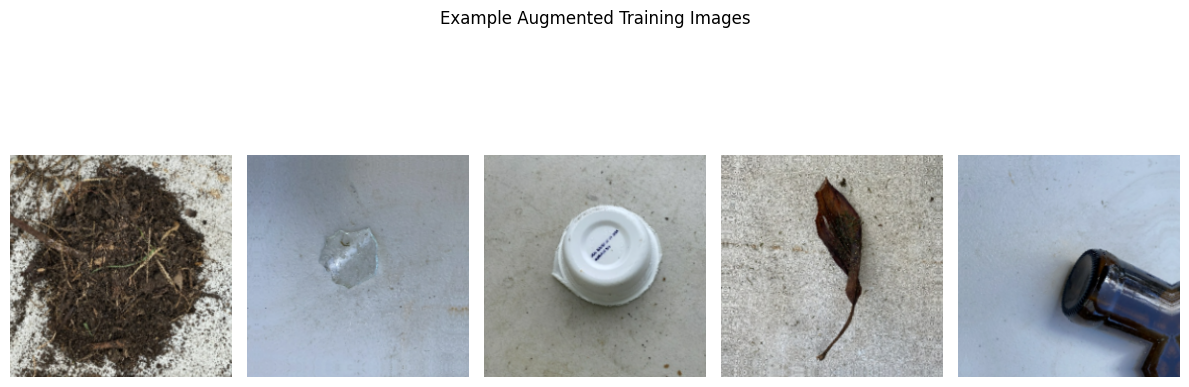

In [8]:
# 2.1 Image preprocessing
# The CNN receives 224 x 224 RGB images. Data augmentation is applied only
# during training; normalization is handled by the MobileNetV2 preprocessing
# function inside the model.

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="data_augmentation")

# Preview one augmented image.
sample_images, sample_labels = next(iter(train_ds.take(1)))
augmented_images = data_augmentation(sample_images, training=True)

plt.figure(figsize=(12, 5))
for i in range(min(5, len(sample_images))):
    ax = plt.subplot(1, 5, i + 1)
    ax.imshow(tf.cast(augmented_images[i], tf.uint8))
    ax.axis("off")
plt.suptitle("Example Augmented Training Images")
plt.tight_layout()
plt.show()

### 2.2 Implement CNN Model with Transfer Learning

In [9]:
# 2.2 CNN model with transfer learning
# MobileNetV2 is used because it is relatively lightweight while providing
# strong image features learned from ImageNet.

try:
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights="imagenet"
    )
    pretrained_available = True
except Exception as e:
    print("ImageNet weights could not be downloaded or loaded.")
    print("Fallback:", type(e).__name__, str(e)[:150])
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights=None
    )
    pretrained_available = False

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="image")
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.35)(x)
x = tf.keras.layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)
x = tf.keras.layers.Dropout(0.25)(x)
outputs = tf.keras.layers.Dense(
    num_classes,
    activation="softmax",
    name="waste_category"
)(x)

cnn_model = tf.keras.Model(inputs, outputs, name="EcoSort_MobileNetV2")

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()
print("\nImageNet pretrained weights available:", pretrained_available)

Model: "EcoSort_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                   │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ waste_category (Dense)               │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,423,113 (9.24 MB)

 Trainable params: 165,129 (645.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


ImageNet pretrained weights available: True


### Model choice
MobileNetV2 is used as the transfer-learning backbone because it provides a compact convolutional architecture suitable for image classification. The pretrained base is initially frozen and a regularized classification head is trained first.

### 2.3 Train and Evaluate the Model

Epoch 1/8


C:\Users\kpaul\.anaconda\Anaconda3\envs\pauline_environment\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


104/104 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.4902 - loss: 1.4218 - val_accuracy: 0.8530 - val_loss: 0.5055 - learning_rate: 0.0010
Epoch 2/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.6634 - loss: 0.9393 - val_accuracy: 0.8766 - val_loss: 0.3926 - learning_rate: 0.0010
Epoch 3/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.7063 - loss: 0.8242 - val_accuracy: 0.9445 - val_loss: 0.2287 - learning_rate: 0.0010
Epoch 4/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.7508 - loss: 0.6867 - val_accuracy: 0.9459 - val_loss: 0.1956 - learning_rate: 0.0010
Epoch 5/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.7562 - loss: 0.6580 - val_accuracy: 0.9459 - val_loss: 0.2340 - learning_rate: 0.0010
Epoch 6/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.7695 - loss: 0.6235 - val_accuracy: 0.9528 - val_loss: 0.2024 - learning_rate: 0.0010
Epoch 7/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.8088 - loss: 0.5344 - val_accura

,accuracy,loss,val_accuracy,val_loss,learning_rate
3,0.750827,0.686723,0.945908,0.195594,0.0010
4,0.756237,0.657997,0.945908,0.233962,0.0010
5,0.769462,0.623499,0.952843,0.202361,0.0010
6,0.808837,0.534353,0.955617,0.190907,0.0003
7,0.809137,0.532928,0.957004,0.175295,0.0003


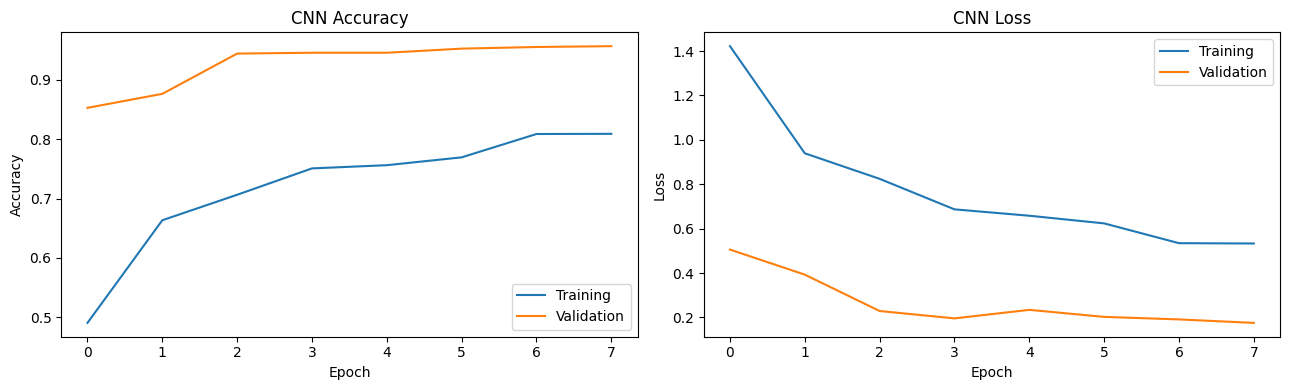

In [10]:
# 2.3 Train the CNN model

# Class weights help reduce the effect of category imbalance.
class_indices = {name: i for i, name in enumerate(class_names)}
present_counts = np.array([class_counts[name] for name in class_names])

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=np.repeat(np.arange(num_classes), present_counts)
)
class_weight = {i: float(w) for i, w in enumerate(weights)}

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6
    )
]

INITIAL_EPOCHS = 8

history = cnn_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks
)

history_df = pd.DataFrame(history.history)
display(history_df.tail())

# Plot training curves.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["accuracy"], label="Training")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("CNN Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Training")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("CNN Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

Test loss: 0.5221
Test accuracy: 0.8068

Classification report:
                     precision    recall  f1-score   support

          Cardboard       0.00      0.00      0.00         0
      Food Organics       0.00      0.00      0.00         0
              Glass       0.00      0.00      0.00         0
              Metal       0.00      0.00      0.00         0
Miscellaneous Trash       0.00      0.00      0.00         0
              Paper       0.00      0.00      0.00         0
            Plastic       1.00      0.80      0.89       671
      Textile Trash       0.97      0.85      0.90        33
         Vegetation       0.00      0.00      0.00         0

           accuracy                           0.81       704
          macro avg       0.22      0.18      0.20       704
       weighted avg       1.00      0.81      0.89       704



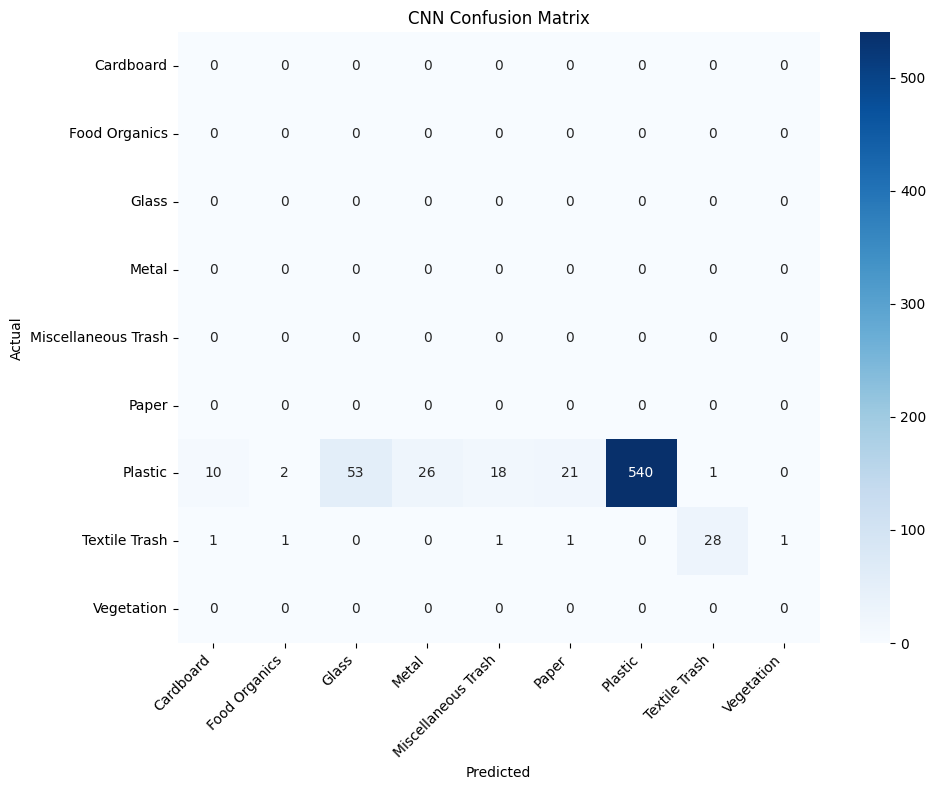

Most common misclassification pairs:
Plastic -> Glass: 53
Plastic -> Metal: 26
Plastic -> Paper: 21
Plastic -> Miscellaneous Trash: 18
Plastic -> Cardboard: 10
Plastic -> Food Organics: 2
Plastic -> Textile Trash: 1
Textile Trash -> Cardboard: 1
Textile Trash -> Food Organics: 1
Textile Trash -> Paper: 1


In [11]:
# 2.3 Evaluate the CNN model

test_loss, test_accuracy = cnn_model.evaluate(test_dataset, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

# Collect true and predicted labels.
y_true_img = []
y_pred_img = []

for images, labels in test_dataset:
    probabilities = cnn_model.predict(images, verbose=0)
    y_true_img.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_img.extend(np.argmax(probabilities, axis=1))

y_true_img = np.array(y_true_img)
y_pred_img = np.array(y_pred_img)

print("\nClassification report:")
print(
    classification_report(
        y_true_img,
        y_pred_img,
        target_names=class_names,
        zero_division=0
    )
)

cm = confusion_matrix(y_true_img, y_pred_img)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Identify the most common error pairs.
error_pairs = Counter(
    (class_names[true], class_names[pred])
    for true, pred in zip(y_true_img, y_pred_img)
    if true != pred
)

print("Most common misclassification pairs:")
for (actual, predicted), count in error_pairs.most_common(10):
    print(f"{actual} -> {predicted}: {count}")

### 2.4 Fine-tune the Model

In [12]:
# 2.4 Fine-tune the CNN
# Unfreeze only the final portion of MobileNetV2 and use a small learning rate.
# This allows the pretrained features to adapt to RealWaste without destabilizing
# the earlier general-purpose visual features.

base_model.trainable = True

# Freeze the earlier layers and fine-tune the last 20 layers.
for layer in base_model.layers[:-20]:
    layer.trainable = False

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=1,
        min_lr=1e-7
    )
]

FINE_TUNE_EPOCHS = 3

fine_tune_history = cnn_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weight,
    callbacks=fine_tune_callbacks
)

fine_test_loss, fine_test_accuracy = cnn_model.evaluate(test_dataset, verbose=0)

print(f"Fine-tuned test loss: {fine_test_loss:.4f}")
print(f"Fine-tuned test accuracy: {fine_test_accuracy:.4f}")

print(
    "\nFine-tuning result:",
    "improved" if fine_test_accuracy >= test_accuracy else "did not improve the held-out accuracy"
)

Epoch 1/3


C:\Users\kpaul\.anaconda\Anaconda3\envs\pauline_environment\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


104/104 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.6940 - loss: 0.8456 - val_accuracy: 0.9570 - val_loss: 0.1695 - learning_rate: 1.0000e-05
Epoch 2/3
104/104 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.7304 - loss: 0.7236 - val_accuracy: 0.9570 - val_loss: 0.1696 - learning_rate: 1.0000e-05
Epoch 3/3
104/104 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.7526 - loss: 0.6895 - val_accuracy: 0.9612 - val_loss: 0.1736 - learning_rate: 3.0000e-06
Fine-tuned test loss: 0.5307
Fine-tuned test accuracy: 0.7940

Fine-tuning result: did not improve the held-out accuracy


## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data

In [13]:
# 3.1 Preprocess text data
# The same cleaning function and TF-IDF representation from Part 1 are reused
# so that training and prediction use an identical preprocessing pipeline.

print("Training examples:", len(X_train_text))
print("Validation examples:", len(X_val_text))
print("Test examples:", len(X_test_text))
print("\nExample cleaned text:")
display(
    pd.DataFrame({
        "clean_text": X_train_text.head(5).values,
        "category": y_train_text.head(5).values
    })
)

Training examples: 3500
Validation examples: 750
Test examples: 750

Example cleaned text:


,clean_text,category
0,ripped industrial cotton styrofoam,Miscellaneous Trash
1,clean regularsized black branches,Vegetation
2,small patterned moving box,Cardboard
3,broken commercial plastic straw,Plastic
4,dry floral gift box,Cardboard


### 3.2 Implement Text Classification Model

In [14]:
# 3.2 Text classification model
# Option A from the assignment is used: TF-IDF features + Logistic Regression.
# This is a strong, interpretable baseline for short generated descriptions.

text_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)

text_model.fit(X_train_tfidf, y_train_text)

print("Text classification model trained.")
print("Number of classes:", len(text_model.classes_))

Text classification model trained.
Number of classes: 9


### Text model choice
The assignment permits either a traditional machine-learning approach or a transformer. A TF-IDF + Logistic Regression model is used here because the supplied descriptions are short and categorical, and this approach is fast, reproducible, and easy to evaluate.

### 3.3 Train and Evaluate the Model

In [15]:
# 3.3 Train/validate the text classification model

val_predictions = text_model.predict(X_val_tfidf)
val_accuracy = accuracy_score(y_val_text, val_predictions)

print(f"Validation accuracy: {val_accuracy:.4f}")

print("\nValidation classification report:")
print(
    classification_report(
        y_val_text,
        val_predictions,
        zero_division=0
    )
)

Validation accuracy: 0.9947

Validation classification report:
                     precision    recall  f1-score   support

          Cardboard       1.00      1.00      1.00        87
      Food Organics       1.00      1.00      1.00        78
              Glass       1.00      1.00      1.00        82
              Metal       0.97      1.00      0.99        76
Miscellaneous Trash       1.00      0.95      0.98        87
              Paper       0.99      1.00      0.99        76
            Plastic       0.99      1.00      0.99        86
      Textile Trash       1.00      1.00      1.00        88
         Vegetation       1.00      1.00      1.00        90

           accuracy                           0.99       750
          macro avg       0.99      0.99      0.99       750
       weighted avg       0.99      0.99      0.99       750



Text test accuracy: 0.9920

Test classification report:
                     precision    recall  f1-score   support

          Cardboard       1.00      1.00      1.00        88
      Food Organics       1.00      1.00      1.00        77
              Glass       0.98      1.00      0.99        83
              Metal       0.97      1.00      0.99        76
Miscellaneous Trash       1.00      0.97      0.98        87
              Paper       0.97      1.00      0.99        76
            Plastic       1.00      1.00      1.00        85
      Textile Trash       1.00      0.97      0.98        88
         Vegetation       1.00      1.00      1.00        90

           accuracy                           0.99       750
          macro avg       0.99      0.99      0.99       750
       weighted avg       0.99      0.99      0.99       750



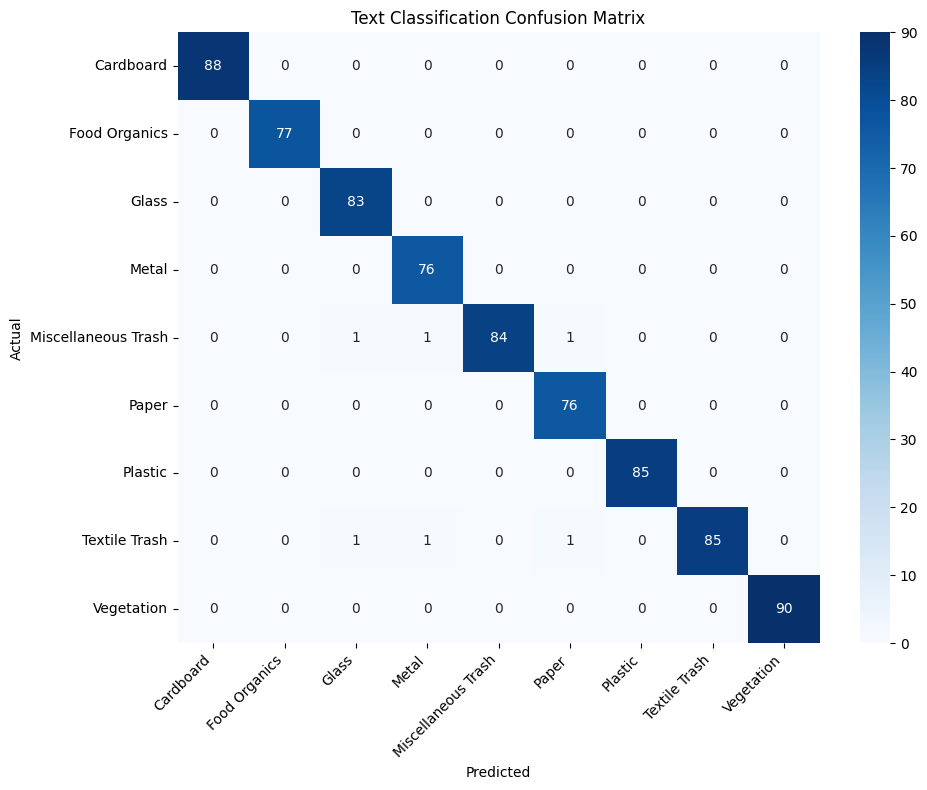

Common text-classification errors:
Textile Trash -> Glass: 1
Miscellaneous Trash -> Metal: 1
Miscellaneous Trash -> Paper: 1
Textile Trash -> Metal: 1
Miscellaneous Trash -> Glass: 1
Textile Trash -> Paper: 1


In [16]:
# 3.3 Evaluate text model on the held-out test set

test_predictions = text_model.predict(X_test_tfidf)
text_test_accuracy = accuracy_score(y_test_text, test_predictions)

print(f"Text test accuracy: {text_test_accuracy:.4f}")

print("\nTest classification report:")
print(
    classification_report(
        y_test_text,
        test_predictions,
        zero_division=0
    )
)

text_labels = sorted(y_test_text.unique())
text_cm = confusion_matrix(
    y_test_text,
    test_predictions,
    labels=text_labels
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    text_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=text_labels,
    yticklabels=text_labels
)
plt.title("Text Classification Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Common text-classification errors:")
text_errors = Counter(
    (actual, predicted)
    for actual, predicted in zip(y_test_text, test_predictions)
    if actual != predicted
)
for (actual, predicted), count in text_errors.most_common(10):
    print(f"{actual} -> {predicted}: {count}")

### 3.4 Create Classification Function

In [17]:
# 3.4 Create classification function

def classify_waste_description(description):
    """
    Classify a waste description into one of the learned waste categories.

    Parameters
    ----------
    description : str
        User-provided description of a waste item.

    Returns
    -------
    dict
        Predicted category and model confidence.
    """
    if not isinstance(description, str) or not description.strip():
        raise ValueError("description must be a non-empty string.")

    cleaned = clean_text(description)
    features = text_vectorizer.transform([cleaned])
    probabilities = text_model.predict_proba(features)[0]
    best_index = int(np.argmax(probabilities))

    return {
        "category": text_model.classes_[best_index],
        "confidence": float(probabilities[best_index])
    }

# Example
example_description = "empty plastic water bottle"
print(classify_waste_description(example_description))

{'category': 'Plastic', 'confidence': 0.9915296906666152}


## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

In [18]:
# 4.1 Prepare documents for retrieval

# policy_df and policy_matrix were created in Part 1.
# Retrieval will return the most relevant policy documents for a waste category.

def retrieve_policy_documents(query, top_k=3):
    """
    Retrieve the most relevant policy documents using cosine similarity
    between TF-IDF vectors.
    """
    if not isinstance(query, str) or not query.strip():
        raise ValueError("query must be a non-empty string.")

    query_vector = rag_vectorizer.transform([clean_text(query)])

    # TF-IDF vectors are L2-normalized by default, so the dot product
    # corresponds to cosine similarity.
    scores = (policy_matrix @ query_vector.T).toarray().ravel()
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = policy_df.iloc[top_indices].copy()
    results["retrieval_score"] = scores[top_indices]

    return results

# Example retrieval
retrieved_example = retrieve_policy_documents("plastic bottle recycling", top_k=3)
display(
    retrieved_example[
        ["policy_type", "retrieval_score", "document_text"]
    ]
)

,policy_type,retrieval_score,document_text
10,Residential Recycling Rules,0.123505,RESIDENTIAL RECYCLING RULES\n\nGENERAL REQUIRE...
3,Plastic Recycling Guidelines,0.112493,PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...
11,Commercial Recycling Standards,0.102698,COMMERCIAL RECYCLING STANDARDS\n\nGENERAL REQU...


### 4.2 Implement RAG-based System

In [19]:
# 4.2 Implement the RAG-based system
# The system combines:
# 1. Retrieval: TF-IDF similarity finds relevant Metro City policy documents.
# 2. Generation: a small pretrained text-to-text transformer is used when the
#    required package/model is available.
# 3. Fallback: if the transformer cannot be loaded, grounded extractive
#    generation still produces policy-based instructions locally.

USE_GENERATIVE_TRANSFORMER = True
generator = None

if USE_GENERATIVE_TRANSFORMER:
    try:
        from transformers import pipeline

        generator = pipeline(
            "text2text-generation",
            model="google/flan-t5-small"
        )
        print("Pretrained generator loaded: google/flan-t5-small")
    except Exception as e:
        print(
            "Pretrained transformer could not be loaded. "
            "Using grounded policy-text fallback."
        )
        print("Reason:", type(e).__name__, str(e)[:200])
        generator = None

def extract_policy_section(document_text, category):
    """Extract the section of a policy document associated with a category."""
    text = str(document_text)
    category_upper = category.upper()

    pattern = rf"{re.escape(category_upper)}\s+GUIDELINES?:"
    match = re.search(pattern, text, flags=re.IGNORECASE)

    if not match:
        return text.strip()

    section_start = match.start()

    next_heading = re.search(
        r"\n[A-Z][A-Z\s&-]{4,}:\n",
        text[match.end():]
    )

    if next_heading:
        section_end = match.end() + next_heading.start()
        return text[section_start:section_end].strip()

    return text[section_start:].strip()

def generate_grounded_instruction(category, retrieved_docs):
    """
    Generate recycling guidance from retrieved policy context.
    When FLAN-T5 is available, generation is constrained by an explicit
    instruction to use only the supplied context.
    """
    sections = []

    for _, row in retrieved_docs.iterrows():
        section = extract_policy_section(
            row["document_text"],
            category
        )
        sections.append({
            "policy_type": row["policy_type"],
            "score": float(row["retrieval_score"]),
            "section": section
        })

    if not sections:
        return (
            f"No matching Metro City policy was retrieved for {category}.",
            []
        )

    context = "\n\n".join(
        f"POLICY SOURCE: {item['policy_type']}\n{item['section']}"
        for item in sections
    )

    if generator is not None:
        prompt = f"""
You are a waste-management assistant.
Waste category: {category}

Use ONLY the policy context below.
Write concise, practical recycling/disposal instructions.
Do not invent collection rules, dates, penalties, or accepted materials.
If the policy does not state something, do not add it.

POLICY CONTEXT:
{context}
"""
        try:
            generated = generator(
                prompt,
                max_new_tokens=180,
                do_sample=False
            )[0]["generated_text"].strip()

            instruction = (
                f"Recycling guidance for {category}:\n\n"
                f"{generated}\n\n"
                "Guidance is grounded in the supplied Metro City policy documents."
            )
        except Exception:
            instruction = (
                f"Recycling guidance for {category}:\n\n"
                f"{sections[0]['section']}\n\n"
                "Guidance is grounded in the supplied Metro City policy documents."
            )
    else:
        instruction = (
            f"Recycling guidance for {category}:\n\n"
            f"{sections[0]['section']}\n\n"
            "Guidance is grounded in the supplied Metro City policy documents."
        )

    return instruction, sections

print("RAG retrieval and generation components are ready.")

C:\Users\kpaul\.anaconda\Anaconda3\envs\pauline_environment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pretrained transformer could not be loaded. Using grounded policy-text fallback.
Reason: KeyError "Unknown task text2text-generation, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 
RAG retrieval and generation components are ready.


C:\Users\kpaul\.anaconda\Anaconda3\envs\pauline_environment\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kpaul\.cache\huggingface\hub\models--google--flan-t5-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


### RAG design choice
The retrieval stage uses TF-IDF similarity over the supplied Metro City policy documents. The response is then generated from retrieved policy text, keeping the instructions grounded in the provided corpus. This avoids introducing unsupported disposal rules.

### 4.3 Adjust and Evaluate the System

In [20]:
# 4.3 Adjust and evaluate the retrieval component
# There is no supervised "training" step for the retrieval index. Instead,
# retrieval quality is checked by querying representative waste categories.

rag_test_categories = class_names
rag_results = []

for category in rag_test_categories:
    retrieved = retrieve_policy_documents(category, top_k=3)
    top_policy = retrieved.iloc[0]

    rag_results.append({
        "category": category,
        "top_policy": top_policy["policy_type"],
        "retrieval_score": top_policy["retrieval_score"]
    })

rag_evaluation_df = pd.DataFrame(rag_results)

print("Generative transformer active:", generator is not None)
print("Top retrieved policy for each category:")
display(rag_evaluation_df)

print(
    "\nMean top-document retrieval score:",
    round(rag_evaluation_df["retrieval_score"].mean(), 4)
)

Generative transformer active: False
Top retrieved policy for each category:


,category,top_policy,retrieval_score
0,Cardboard,Cardboard Recycling Guidelines,0.249250
1,Food Organics,Commercial Recycling Standards,0.156035
2,Glass,Glass Recycling Guidelines,0.241143
3,Metal,Metal Recycling Guidelines,0.191251
4,Miscellaneous Trash,Municipal Waste Guidelines,0.135298
5,Paper,Paper Recycling Guidelines,0.284479
6,Plastic,Plastic Recycling Guidelines,0.141349
7,Textile Trash,Multi-Unit Building Guidelines,0.139695
8,Vegetation,Vegetation Recycling Guidelines,0.136447



Mean top-document retrieval score: 0.1861


In [21]:
# 4.3 Evaluate the quality of generated instructions
# A simple groundedness check verifies that the generated instruction contains
# content retrieved from the policy corpus.

def evaluate_rag_category(category):
    retrieved = retrieve_policy_documents(category, top_k=3)
    instruction, sources = generate_grounded_instruction(category, retrieved)

    source_text = " ".join(s["section"] for s in sources).lower()
    instruction_text = instruction.lower()

    grounded = any(
        phrase.strip() and phrase.strip().lower() in instruction_text
        for phrase in source_text.split(".")
        if len(phrase.strip()) > 20
    )

    return {
        "category": category,
        "grounded_in_retrieved_policy": grounded,
        "sources_used": len(sources),
        "top_source": sources[0]["policy_type"] if sources else None
    }

rag_quality_df = pd.DataFrame(
    [evaluate_rag_category(category) for category in class_names]
)

display(rag_quality_df)

print(
    f"Grounded outputs: {rag_quality_df['grounded_in_retrieved_policy'].sum()}/"
    f"{len(rag_quality_df)}"
)

,category,grounded_in_retrieved_policy,sources_used,top_source
0,Cardboard,True,3,Cardboard Recycling Guidelines
1,Food Organics,False,3,Commercial Recycling Standards
2,Glass,True,3,Glass Recycling Guidelines
3,Metal,True,3,Metal Recycling Guidelines
4,Miscellaneous Trash,False,3,Municipal Waste Guidelines
5,Paper,True,3,Paper Recycling Guidelines
6,Plastic,True,3,Plastic Recycling Guidelines
7,Textile Trash,False,3,Multi-Unit Building Guidelines
8,Vegetation,True,3,Vegetation Recycling Guidelines


Grounded outputs: 6/9


### 4.4 Create Instruction Generation Function

In [22]:
# 4.4 Create instruction generation function

def generate_recycling_instructions(waste_category):
    """
    Generate recycling instructions for a waste category using retrieved
    Metro City policy documents.

    Returns
    -------
    dict
        Category, generated instructions, and retrieved policy sources.
    """
    if not isinstance(waste_category, str) or not waste_category.strip():
        raise ValueError("waste_category must be a non-empty string.")

    # Match category case-insensitively to the model's known categories.
    normalized = {
        category.lower(): category
        for category in class_names
    }

    category = normalized.get(waste_category.lower())
    if category is None:
        raise ValueError(
            f"Unknown waste category '{waste_category}'. "
            f"Choose from: {class_names}"
        )

    retrieved = retrieve_policy_documents(category, top_k=3)
    instructions, sources = generate_grounded_instruction(
        category,
        retrieved
    )

    return {
        "category": category,
        "instructions": instructions,
        "policy_sources": [
            {
                "policy_type": source["policy_type"],
                "retrieval_score": source["score"]
            }
            for source in sources
        ]
    }

# Example
display(generate_recycling_instructions("Plastic"))

{'category': 'Plastic',
 'instructions': 'Recycling guidance for Plastic:\n\nPLASTIC RECYCLING GUIDELINES\n\nAcceptable Items:\n- PET bottles and containers (code #1)\n- HDPE containers (code #2)\n- PP containers (code #5)\n- Clean plastic packaging\n\nNon-Acceptable Items:\n- Plastic bags and film\n- Polystyrene foam (code #6)\n- Containers with food residue\n- Mixed material packaging\n- Black plastic containers\n\nCollection Method:\nPlace in dedicated recycling bins. Check local guidelines for specific plastic types accepted.\n\nPreparation Instructions:\n- Rinse containers\n- Remove lids and caps (recycle separately)\n- Check for recycling codes (1-7)\n\nBenefits:\nPlastic recycling reduces petroleum consumption and greenhouse gas emissions.\n\nGuidance is grounded in the supplied Metro City policy documents.',
 'policy_sources': [{'policy_type': 'Plastic Recycling Guidelines',
   'retrieval_score': 0.1413494021188438},
  {'policy_type': 'Municipal Waste Guidelines',
   'retrieval

## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

In [23]:
# 5.1 Integration architecture

# Input
#   |
#   +--> Image --> CNN classifier --> waste category + confidence
#   |
#   +--> Text  --> TF-IDF + Logistic Regression --> waste category + confidence
#                         |
#                         v
#                 Policy Retriever (RAG)
#                         |
#                         v
#              Grounded recycling instructions
#
# The integration layer below standardizes both input routes so that the
# downstream policy retrieval receives the same category representation.

def predict_image(image_input):
    """Predict a waste category from an image path, PIL image, or NumPy array."""
    if isinstance(image_input, (str, pathlib.Path)):
        image = Image.open(image_input).convert("RGB")
    elif isinstance(image_input, Image.Image):
        image = image_input.convert("RGB")
    elif isinstance(image_input, np.ndarray):
        image = Image.fromarray(image_input.astype("uint8")).convert("RGB")
    else:
        raise TypeError(
            "Image input must be a file path, PIL Image, or NumPy array."
        )

    image = image.resize((IMG_WIDTH, IMG_HEIGHT))
    array = np.asarray(image, dtype=np.float32)
    batch = np.expand_dims(array, axis=0)

    probabilities = cnn_model.predict(batch, verbose=0)[0]
    index = int(np.argmax(probabilities))

    return {
        "category": class_names[index],
        "confidence": float(probabilities[index])
    }

print("Integration architecture defined.")

Integration architecture defined.


### Integration flow
The assistant has two entry points—image and text—but both produce the same intermediate representation: a waste category and confidence. That category is passed to the policy retrieval/generation layer.

### 5.2 Implement Integrated Assistant

In [24]:
# 5.2 Implement the integrated waste management assistant

def waste_management_assistant(input_data, input_type="image"):
    """
    Process an image or text description and return classification plus
    policy-grounded recycling guidance.

    Parameters
    ----------
    input_data : path/PIL image/NumPy array/str
        Image data when input_type='image'; description when input_type='text'.
    input_type : {'image', 'text'}
        Determines which classifier is used.

    Returns
    -------
    dict
        Classification, confidence, recycling instructions, and policy sources.
    """
    input_type = input_type.lower()

    if input_type == "image":
        classification = predict_image(input_data)
    elif input_type == "text":
        classification = classify_waste_description(input_data)
    else:
        raise ValueError("input_type must be either 'image' or 'text'.")

    recycling = generate_recycling_instructions(
        classification["category"]
    )

    return {
        "input_type": input_type,
        "category": classification["category"],
        "confidence": classification["confidence"],
        "recycling_instructions": recycling["instructions"],
        "policy_sources": recycling["policy_sources"]
    }

# Example text-based assistant query.
example_result = waste_management_assistant(
    "an empty plastic water bottle",
    input_type="text"
)

print("Category:", example_result["category"])
print("Confidence:", round(example_result["confidence"], 4))
print("\nInstructions:")
print(example_result["recycling_instructions"])
print("\nPolicy sources:")
display(pd.DataFrame(example_result["policy_sources"]))

Category: Plastic
Confidence: 0.9915

Instructions:
Recycling guidance for Plastic:

PLASTIC RECYCLING GUIDELINES

Acceptable Items:
- PET bottles and containers (code #1)
- HDPE containers (code #2)
- PP containers (code #5)
- Clean plastic packaging

Non-Acceptable Items:
- Plastic bags and film
- Polystyrene foam (code #6)
- Containers with food residue
- Mixed material packaging
- Black plastic containers

Collection Method:
Place in dedicated recycling bins. Check local guidelines for specific plastic types accepted.

Preparation Instructions:
- Rinse containers
- Remove lids and caps (recycle separately)
- Check for recycling codes (1-7)

Benefits:
Plastic recycling reduces petroleum consumption and greenhouse gas emissions.

Guidance is grounded in the supplied Metro City policy documents.

Policy sources:


,policy_type,retrieval_score
0,Plastic Recycling Guidelines,0.141349
1,Municipal Waste Guidelines,0.141323
2,Residential Recycling Rules,0.112827


### 5.3 Evaluate the Integrated System

In [25]:
# 5.3 Evaluate the integrated system

# Text-based end-to-end evaluation.
integrated_text_results = []

for description, actual in zip(
    X_test_text.head(100),
    y_test_text.head(100)
):
    result = waste_management_assistant(description, input_type="text")

    integrated_text_results.append({
        "description": description,
        "actual": actual,
        "predicted": result["category"],
        "confidence": result["confidence"]
    })

integrated_text_df = pd.DataFrame(integrated_text_results)

integrated_accuracy = accuracy_score(
    integrated_text_df["actual"],
    integrated_text_df["predicted"]
)

print(
    f"Integrated text classification accuracy on the sampled test set: "
    f"{integrated_accuracy:.4f}"
)

display(integrated_text_df.head(10))

# Demonstrate the image route with one image from the test data directory.
test_image_files = [
    p for p in data_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

if test_image_files:
    demo_image = random.choice(test_image_files)
    image_result = waste_management_assistant(
        demo_image,
        input_type="image"
    )

    print("\nImage assistant demonstration")
    print("Image:", demo_image)
    print("Predicted category:", image_result["category"])
    print("Confidence:", round(image_result["confidence"], 4))
    print("\nInstructions:")
    print(image_result["recycling_instructions"])
else:
    print("No test image was found for the image-route demonstration.")

Integrated text classification accuracy on the sampled test set: 1.0000


,description,actual,predicted,confidence
0,medium avocado pit with contents,Food Organics,Food Organics,0.842260
1,torn green foil wrapper,Metal,Metal,0.640317
2,pink office paper partially filled,Paper,Paper,0.767850
3,partial local baby clothes,Textile Trash,Textile Trash,0.764254
4,dry leather baby clothes leaking,Textile Trash,Textile Trash,0.883309
5,used mini orange artisanal hat,Textile Trash,Textile Trash,0.390113
6,wrinkled cd case with food residue,Plastic,Plastic,0.716637
7,used regularsized silver wooden budget silk tie,Textile Trash,Textile Trash,0.665672
8,patterned wine bottle,Glass,Glass,0.877687
9,soiled tiny purple wooden vacuum cleaner bag,Miscellaneous Trash,Miscellaneous Trash,0.779374



Image assistant demonstration
Image: RealWaste\realwaste-main\RealWaste\Glass\Glass_139.jpg
Predicted category: Glass
Confidence: 0.9872

Instructions:
Recycling guidance for Glass:

GLASS RECYCLING GUIDELINES

Acceptable Items:
- Glass bottles (all colors)
- Glass jars
- Glass food containers
- Glass beverage containers

Non-Acceptable Items:
- Window glass or mirrors
- Drinking glasses
- Ceramics or pottery
- Light bulbs
- Pyrex or heat-resistant glass

Collection Method:
Place in dedicated glass recycling bins. Some areas require color sorting.

Preparation Instructions:
- Rinse containers
- Remove caps and lids (recycle separately)
- Labels can remain

Benefits:
Glass is 100% recyclable and can be recycled endlessly without loss of quality.

Guidance is grounded in the supplied Metro City policy documents.


## Final Conclusion

The completed EcoSort pipeline combines three components:

1. **Image classification:** MobileNetV2 transfer learning with augmentation, regularization, evaluation, and fine-tuning.
2. **Text classification:** TF-IDF features with Logistic Regression, evaluated using accuracy, classification report, and confusion matrix.
3. **Policy-grounded RAG:** TF-IDF retrieval over the supplied Metro City policy documents, followed by a small pretrained text-to-text transformer when available, with a grounded local fallback.

The integrated assistant accepts either an image or a text description, predicts a waste category, and uses the predicted category to retrieve relevant policy guidance.

### Important interpretation
The reported model metrics should be read from the executed notebook outputs after the supplied datasets are placed beside the notebook. The notebook intentionally does not hard-code performance values.

### Limitations
- The image dataset contains category imbalance, so class weighting is used during CNN training.
- Text descriptions are generated/simulated data and may not represent every way residents describe waste.
- RAG quality depends on the completeness and accuracy of the supplied policy documents.
- The recycling guidance is a demonstration system based on the assignment's Metro City policy corpus; real deployment would require validation against the current official municipal rules.

## Submission Guidelines

1. Make sure all code cells are properly commented and annotated
2. Ensure that all functions are implemented and working correctly
3. Verify that all evaluation metrics are calculated and analyzed
4. Double-check that the integrated system works as expected
5. Submit your completed and annotated Jupyter notebook file

Remember to demonstrate your understanding of the underlying concepts and provide justification for your design decisions throughout the notebook.